In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
df = pd.DataFrame({
    'area':[2600,3000,3200,3600,4000],
    'price':[550000, 570000,600000, 650000, 700000]
})
df

,area,price
0,2600,550000
1,3000,570000
2,3200,600000
3,3600,650000
4,4000,700000


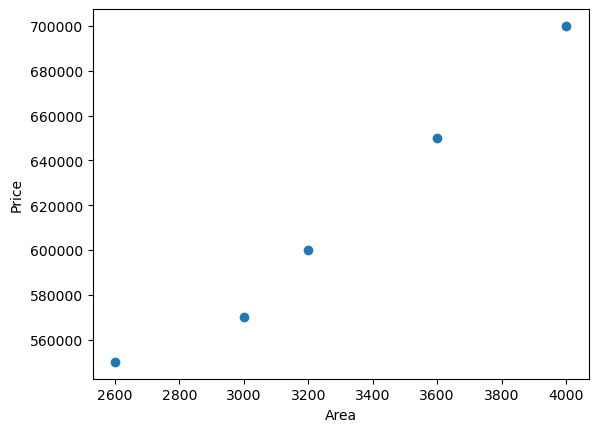

In [7]:
plt.xlabel('Area')
plt.ylabel('Price')
plt.scatter(df['area'], df['price'])

In [9]:
lr = LinearRegression()
lr.fit(df[['area']], df.price)

LinearRegression()

In [12]:
lr.predict([[4500]])

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([750205.47945205])

In [14]:
lr.coef_

array([111.64383562])

In [15]:
lr.intercept_

247808.2191780822

In [20]:
score =lr.score(df[['area']],df['price'])*100

In [21]:
score

97.57611370230269

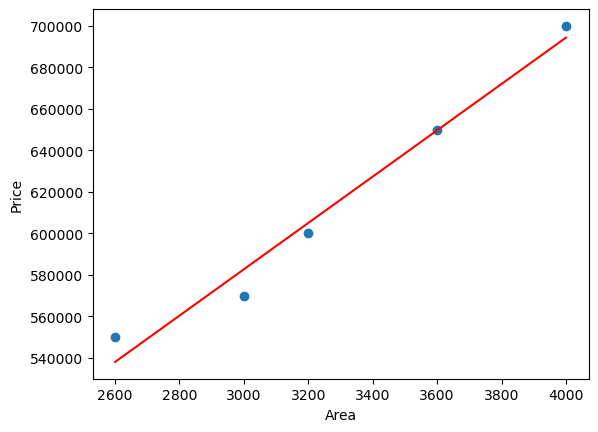

In [24]:
plt.xlabel('Area')
plt.ylabel('Price')
plt.scatter(df['area'], df['price'])
plt.plot(df.area, lr.predict(df[['area']]),color='red')

In [35]:
# let's add more columns in our dataset
df1 = pd.DataFrame({
    'area':[2600,3000,3200,3600,4000],
    'price':[550000, 570000,600000, 650000, 700000],
    'bedroom':[3,4,None,3,5],
    'age':[20,15,18,30,5]
})

In [36]:
df1

,area,price,bedroom,age
0,2600,550000,3.0,20
1,3000,570000,4.0,15
2,3200,600000,NaN,18
3,3600,650000,3.0,30
4,4000,700000,5.0,5


In [58]:
import math
median =math.floor(df1.bedroom.median())
df1.fillna(median, inplace=True)

In [59]:
X=df1.drop(columns=['price'])


In [60]:
y=df1['price']

In [61]:
lr.fit(X,y)

LinearRegression()

In [62]:
lr.coef_

array([  114.44438439, -4815.15511837,  -383.20181602])

In [63]:
lr.intercept_

262701.32958599064

In [68]:
res= lr.predict([[2800, 2,16]])

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [74]:
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/vsWrXfO3wWw?si=NNMI1w1T18SDJAOe" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

In [78]:
x=np.array([1,2,3,4,5])
y=np.array([5,7,9,11,13])

In [95]:
def gradient_descent(x,y):
    m_curr = b_curr =0
    iterations=100
    learning_rate = 0.08
    n=len(x)
    for i in range(iterations):
        y_pred = m_curr * x + b_curr
        cost = (1/n)*sum([val**2 for val in (y-y_pred)])
        
        md = -(2 / n) * sum(x * (y - y_pred))  
        bd = -(2 / n) * sum(y - y_pred)
        m_curr=m_curr-learning_rate*md
        b_curr = b_curr-learning_rate*bd
        print("m_curr  {} , b_curr  {} , iterations  {}, cost {} ".format(m_curr, b_curr, iterations, cost))
        
gradient_descent(x,y)

m_curr  4.96 , b_curr  1.44 , iterations  100, cost 89.0 
m_curr  0.4991999999999983 , b_curr  0.26879999999999993 , iterations  100, cost 71.10560000000002 
m_curr  4.451584000000002 , b_curr  1.426176000000001 , iterations  100, cost 56.8297702400001 
m_curr  0.892231679999997 , b_curr  0.5012275199999995 , iterations  100, cost 45.43965675929613 
m_curr  4.041314713600002 , b_curr  1.432759910400001 , iterations  100, cost 36.35088701894832 
m_curr  1.2008760606719973 , b_curr  0.7036872622079998 , iterations  100, cost 29.097483330142282 
m_curr  3.7095643080294423 , b_curr  1.4546767911321612 , iterations  100, cost 23.307872849944438 
m_curr  1.4424862661541864 , b_curr  0.881337636696883 , iterations  100, cost 18.685758762535738 
m_curr  3.4406683721083144 , b_curr  1.4879302070713722 , iterations  100, cost 14.994867596913156 
m_curr  1.6308855378034224 , b_curr  1.0383405553279617 , iterations  100, cost 12.046787238456794 
m_curr  3.2221235247119777 , b_curr  1.5293810083298

In [97]:
# save model

import pickle

In [98]:
with open('model_pkl','wb') as f:
    pickle.dump(lr,f)    #will convert model in binary file

In [99]:
# use the model

with open('model_pkl','rb') as f:
    model=pickle.load(f)
model.predict([[4800, 4,16]])

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([786642.52513242])

In [105]:
# trying simple load without read or readline similar to jobline mentioned below 
model =pickle.load('model_pkl')
model.predict([[2800, 2,16]])  #throws error

TypeError: file must have 'read' and 'readline' attributes

In [100]:
# dump model using joblib - different from pickle and handles numpy arrays more efficiently

from sklearn.externals import joblib    #deprecated a long time ago

ImportError: cannot import name 'joblib' from 'sklearn.externals' (C:\Users\pc\anaconda3\Lib\site-packages\sklearn\externals\__init__.py)

In [101]:
import joblib

In [102]:
joblib.dump(lr,'model_joblib')

['model_joblib']

In [103]:
mj = joblib.load('model_joblib')

In [104]:
mj.predict([[5800, 4,26]])

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([897254.8913631])